In [2]:
import numpy as np
import matplotlib.pyplot as plt
from spatialmath.base import angle_wrap

In [9]:
kp_v = 0.5
kp_w = 2.0

max_v = 1.0
max_w = np.pi/4

def _angle_diff(angle1, angle2):
    return angle_wrap(angle1 - angle2, mode='-pi:pi')

def compute_v_omega_pid(x_curr, x_goal):
    xc, yc, thetac = x_curr
    xg, yg = x_goal
    dx, dy = xg - xc, yg - yc
    
    # Distance and angle to goal
    rho = np.hypot(dx, dy)
    goal_theta = np.arctan2(dy, dx)
    heading_error = _angle_diff(goal_theta, thetac)

    # PID control (we're only using P here for simplicity)
    v = kp_v * rho
    w = kp_w * heading_error

    # Clamp
    v = np.clip(v, -max_v, max_v)
    w = np.clip(w, -max_w, max_w)

    return v, w

x0 = np.array([0, 0, 0])
xg = np.array([1, 1])
dt = 0.01

xhist = [x0]

while np.linalg.norm(xg - xhist[-1][:2]) > 0.01:
    xc = xhist[-1]
    v, w = compute_v_omega_pid(xc, xg)
    
    xhist.append(xc + np.array([
        v * np.cos(xc[2]) * dt,
        v * np.sin(xc[2]) * dt,
        w * dt
    ]))

(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

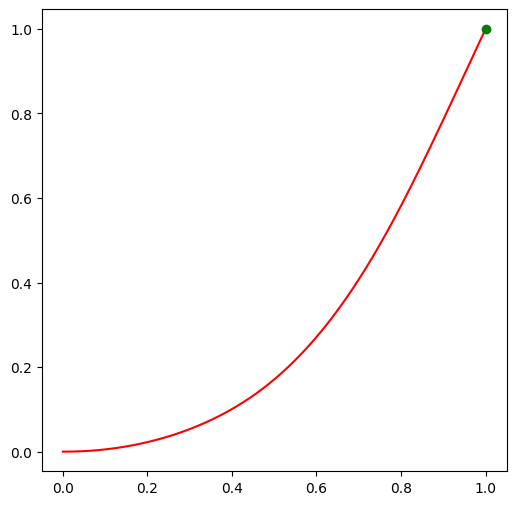

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.plot([x[0] for x in xhist], [x[1] for x in xhist], 'r-')
ax.plot(xg[0], xg[1], 'go')
ax.axis('equal')

In [12]:
import numpy as np
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt

# Example binary map: 1 = free, 0 = obstacle
grid = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

# 1. Compute distance from free cells to obstacles
distance = distance_transform_edt(grid)

distance

array([[0., 0., 0., 0., 0.],
       [0., 1., 1., 1., 0.],
       [0., 1., 2., 1., 0.],
       [0., 1., 1., 1., 0.],
       [0., 0., 0., 0., 0.]])